In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
# -----------------------------
# Load dataset
# -----------------------------
file_path = "Z:/Machine_learning Dr. Vimina/Machine Learning 2026/BCA H 2026/ML Lab Programs/iris.csv"

data = pd.read_csv(file_path)

print("Original Dataset")
print(data.head())

Original Dataset
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
print(data.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [4]:
# -----------------------------
# Encode Categorical Labels
# -----------------------------
encoder = LabelEncoder()

data["species"] = encoder.fit_transform(data["species"])

print("\nEncoded Labels")
print(data.head())



Encoded Labels
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [5]:
# -----------------------------
# Separate Features and Target
# -----------------------------
X = data.drop(columns=["species"])
y = data["species"]


In [6]:
#check the species labels
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64


In [7]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nPreprocessing Completed Successfully!")


Training Samples : 120
Testing Samples  : 30

Preprocessing Completed Successfully!


In [8]:
# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nScaled Features (First 5 rows)")
print(X_train_scaled[:5])



Scaled Features (First 5 rows)
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


In [9]:
# 4. Create Decision Tree
dt = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)

In [10]:
# --------------------------------------------------
# 4. Train the model
# --------------------------------------------------
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [11]:
# --------------------------------------------------
# 5. Make predictions
# --------------------------------------------------
y_pred = dt.predict(X_test_scaled)


In [12]:
# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



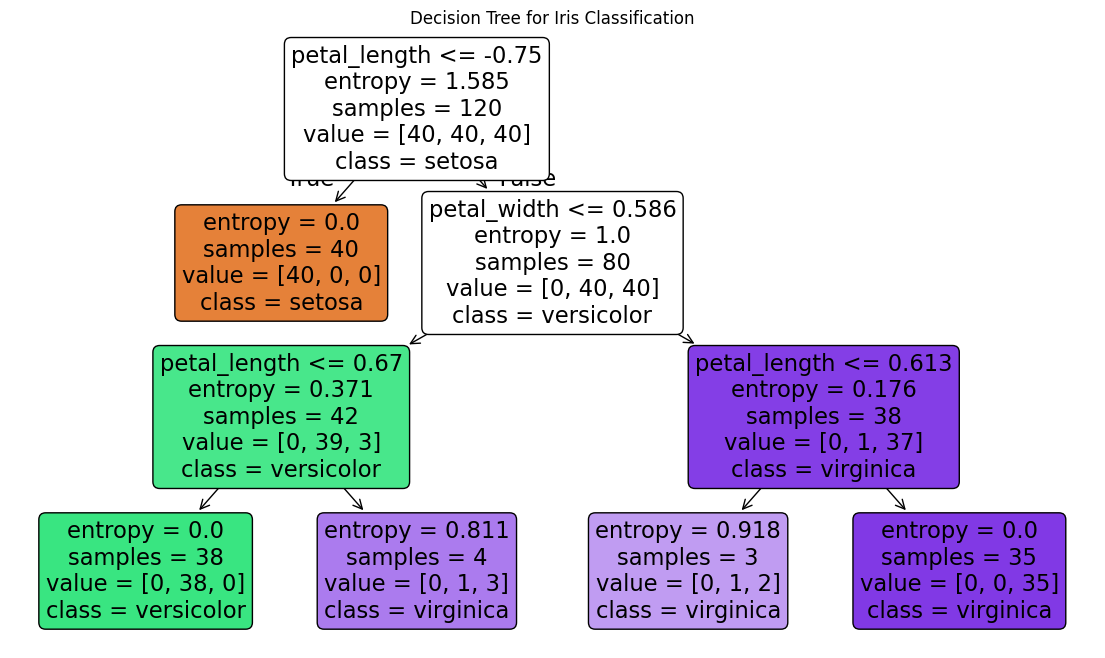

In [13]:
plt.figure(figsize=(14, 8))

plot_tree(dt,feature_names=X.columns, class_names=encoder.classes_, filled=True, rounded=True)

plt.title("Decision Tree for Iris Classification")
plt.show()

In [14]:
# Predict a new flower
sample = [[5.1, 3.5, 1.4, 0.2]]

# Scale the sample
sample_scaled = scaler.transform(sample)

# Predict the class
prediction = dt.predict(sample_scaled)

print("\nPredicted Species:", prediction)


Predicted Species: [0]


c:\Users\viminaer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
